In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

TASK1

In [6]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

data = load_wine()
X = data.data
inertia = []
silhouette = []
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    print(f"Cluster centers shape: {kmeans.cluster_centers_.shape}")
    print(f"Unique labels: {set(labels)}")
    print(f"Inertia (WCSS): {kmeans.inertia_:.2f}")
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, labels)
    print(f"Silhouette Score: {score:.3f}")
    print("\n---------------------")
    silhouette.append(silhouette_score(X_scaled, labels))


Cluster centers shape: (2, 13)
Unique labels: {np.int32(0), np.int32(1)}
Inertia (WCSS): 1658.76
Silhouette Score: 0.259

---------------------
Cluster centers shape: (3, 13)
Unique labels: {np.int32(0), np.int32(1), np.int32(2)}
Inertia (WCSS): 1277.93
Silhouette Score: 0.285

---------------------
Cluster centers shape: (4, 13)
Unique labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}
Inertia (WCSS): 1175.43
Silhouette Score: 0.260

---------------------
Cluster centers shape: (5, 13)
Unique labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}
Inertia (WCSS): 1109.51
Silhouette Score: 0.202

---------------------
Cluster centers shape: (6, 13)
Unique labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)}
Inertia (WCSS): 1046.00
Silhouette Score: 0.237

---------------------
Cluster centers shape: (7, 13)
Unique labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)}
Inertia (WCS

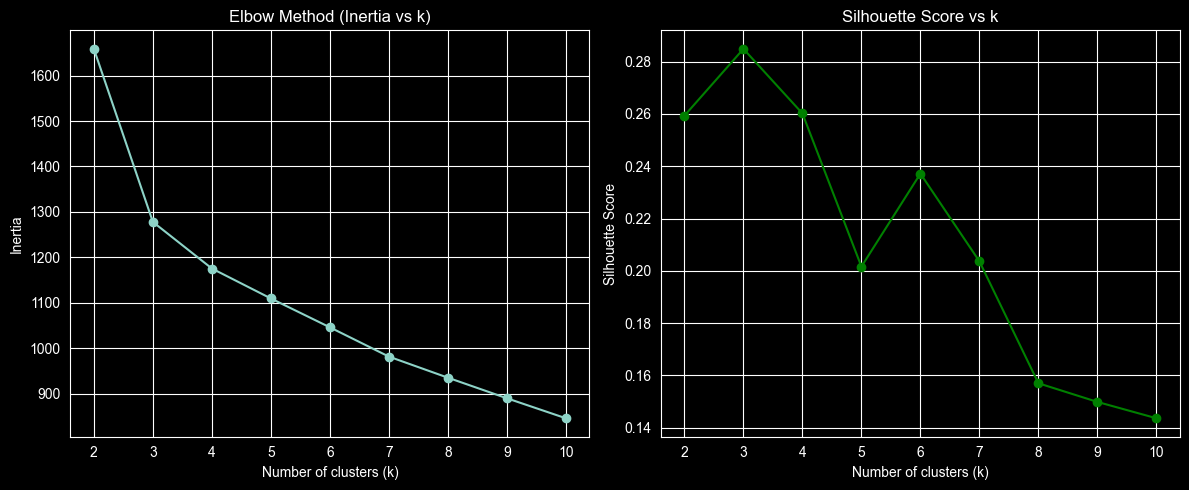

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Elbow plot
plt.subplot(1, 2, 1)
plt.plot(range(2,11), inertia, marker='o')
plt.title("Elbow Method (Inertia vs k)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")

# Silhouette plot
plt.subplot(1, 2, 2)
plt.plot(range(2,11), silhouette, marker='o', color='green')
plt.title("Silhouette Score vs k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

The elbow plot shows a clear bend at k ≈ 3, indicating diminishing returns in inertia reduction beyond this point.

The silhouette score is highest at k = 2, but k = 3 also has a strong score and provides more meaningful cluster separation.

Since the Wine dataset is known to contain 3 classes, and both metrics reasonably support k = 3, we choose:

**Final choice: k = 3**

This balances interpretability and clustering quality.

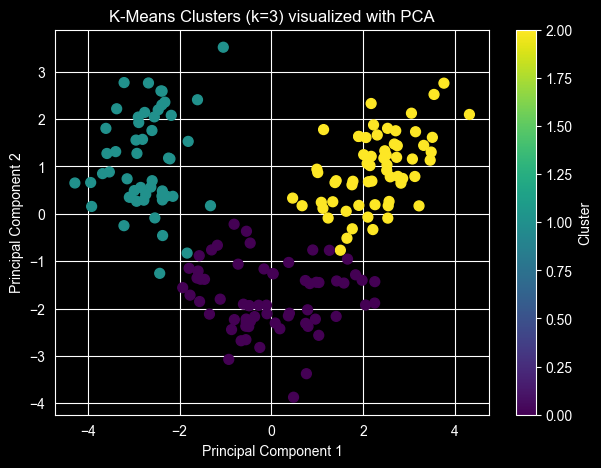

In [11]:
from sklearn.decomposition import PCA

k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_final, cmap='viridis', s=50)

plt.title("K-Means Clusters (k=3) visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

Where does the elbow appear?
Around k = 3, where inertia starts decreasing more slowly.


Do silhouette and elbow agree?
Mostly. Silhouette may slightly favor k = 2, but k = 3 is also strong and aligns with the elbow and known structure of the dataset.

TASK2

In [12]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)

agglo_labels[:10]  # preview

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

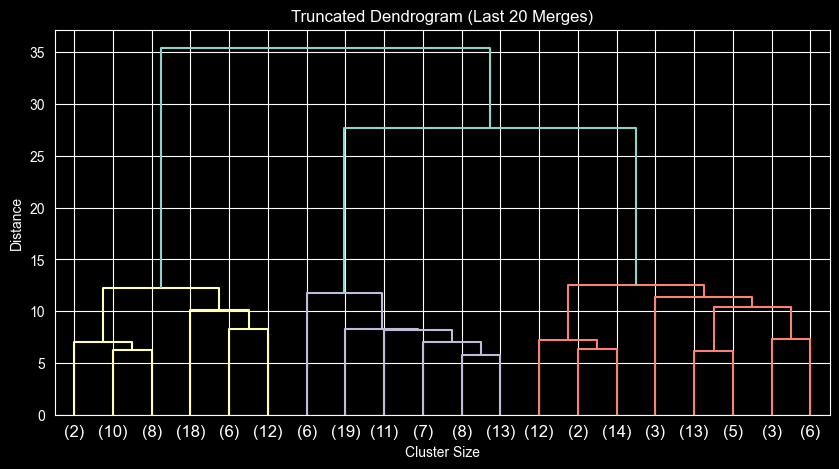

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Compute linkage matrix (Ward method)
Z = linkage(X_scaled, method='ward')

# Plot truncated dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title("Truncated Dendrogram (Last 20 Merges)")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

In [14]:
from sklearn.cluster import DBSCAN
import numpy as np

configs = [
    {"eps": 1.5, "min_samples": 5},
    {"eps": 2.0, "min_samples": 5},
    {"eps": 2.5, "min_samples": 5},
]

dbscan_results = []

for cfg in configs:
    db = DBSCAN(eps=cfg["eps"], min_samples=cfg["min_samples"])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    dbscan_results.append((cfg, n_clusters, n_noise, labels))

    print(f"Config {cfg}: clusters={n_clusters}, noise points={n_noise}")

Config {'eps': 1.5, 'min_samples': 5}: clusters=0, noise points=178
Config {'eps': 2.0, 'min_samples': 5}: clusters=5, noise points=85
Config {'eps': 2.5, 'min_samples': 5}: clusters=1, noise points=24


In [15]:
# Choose best config (closest to k=3)
best_result = min(dbscan_results, key=lambda x: abs(x[1] - 3))

best_cfg, best_clusters, best_noise, dbscan_labels = best_result

print("Best config:", best_cfg)
print("Clusters:", best_clusters, "Noise points:", best_noise)

Best config: {'eps': 2.0, 'min_samples': 5}
Clusters: 5 Noise points: 85


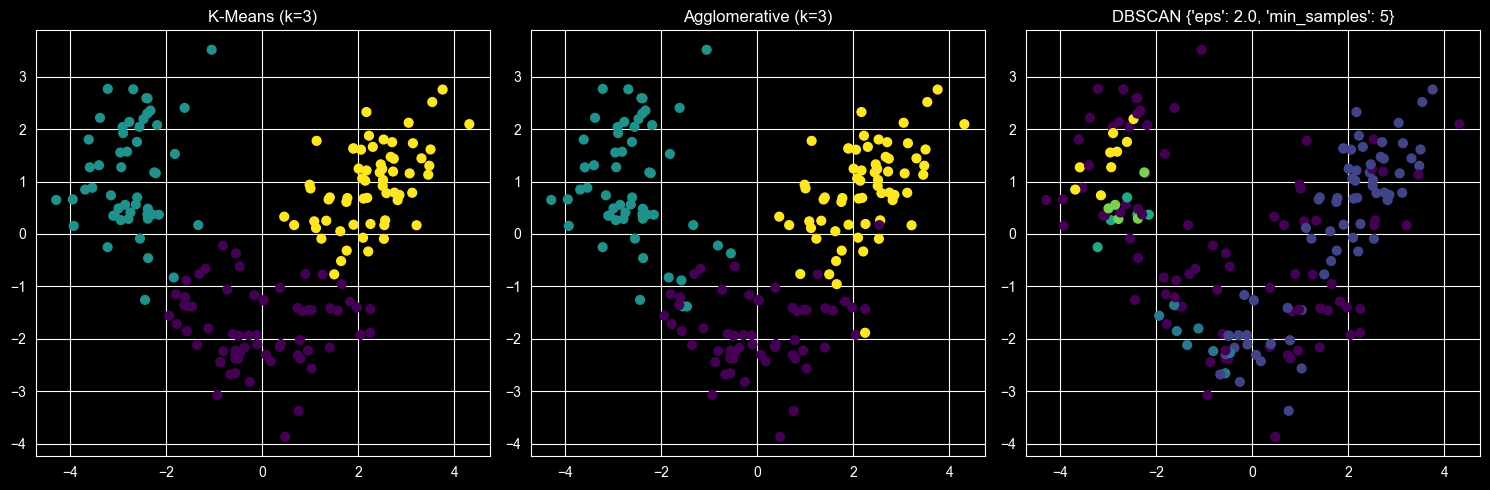

In [16]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Refit KMeans (for completeness)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(15, 5))

# K-Means
plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=40)
plt.title("K-Means (k=3)")

# Agglomerative
plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='viridis', s=40)
plt.title("Agglomerative (k=3)")

# DBSCAN
plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', s=40)
plt.title(f"DBSCAN {best_cfg}")

plt.tight_layout()
plt.show()

### Comparison of Clustering Methods

**K-Means vs Agglomerative:**
Both methods produce very similar cluster structures. This is expected because:
- Both use distance-based grouping
- Ward linkage in Agglomerative is conceptually similar to minimizing variance (like K-Means)

Agglomerative clustering may show slightly different boundaries due to its hierarchical nature, but overall the clusters are coherent and align well.

**DBSCAN:**
DBSCAN behaves differently:
- It may identify fewer or more than 3 clusters depending on `eps`
- It often labels some points as noise (-1)
- Clusters are density-based rather than spherical

Even with the best configuration, DBSCAN may:
- Merge clusters that are close
- Split clusters unevenly
- Mark edge points as noise

**Which is best?**
- **Most coherent clusters:** K-Means and Agglomerative (very similar and stable)
- **Most flexible:** DBSCAN (captures density and noise but less aligned with true structure here)

**Where do they disagree?**
- DBSCAN disagrees the most, especially near cluster boundaries
- K-Means and Agglomerative differ slightly in assignment of borderline points

**Conclusion:**
For the Wine dataset, which has well-separated, compact clusters:
- K-Means and Agglomerative are more appropriate
- DBSCAN is less effective due to its sensitivity to density parameters

TASK3

In [17]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = sns.load_dataset("penguins")

# Drop missing values
df = df.dropna()

# Select numeric features
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X = df[features]

# Labels
y = df["species"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# MDS
mds = MDS(n_components=2, random_state=42, dissimilarity='euclidean')
X_mds = mds.fit_transform(X_scaled)

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


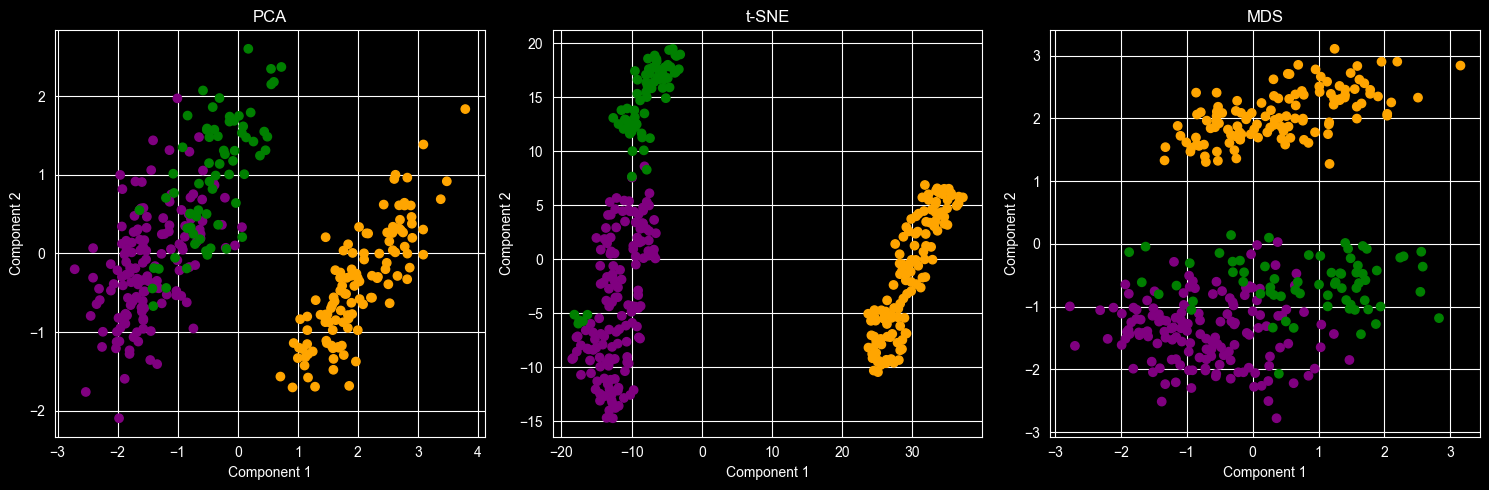

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Map species to consistent colors
species_unique = y.unique()
color_map = dict(zip(species_unique, ["purple", "green", "orange"]))
colors = y.map(color_map)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors)
axes[0].set_title("PCA")

# t-SNE
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors)
axes[1].set_title("t-SNE")

# MDS
axes[2].scatter(X_mds[:, 0], X_mds[:, 1], c=colors)
axes[2].set_title("MDS")

for ax in axes:
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.tight_layout()
plt.show()

### Comparison of Dimensionality Reduction Methods

**Which method best separates the species?**
t-SNE typically provides the clearest visual separation between the three penguin species. It is specifically designed to preserve local neighborhood structure, making clusters appear more distinct and compact.

**Which method distorts inter-cluster distances the most?**
t-SNE distorts global distances the most. While clusters look well separated, the distances between them are not meaningful. Two clusters appearing far apart in t-SNE space are not necessarily far apart in the original feature space.

MDS tries to preserve pairwise distances globally, while PCA preserves variance along linear directions, making both more faithful to overall structure than t-SNE.

**Why might t-SNE give different results on repeated runs?**
t-SNE is stochastic:
- It uses random initialization
- Optimization is non-convex (can converge to different local minima)

Even with a fixed random_state, small parameter changes (like perplexity) can significantly alter the output. Without a fixed seed, results may vary noticeably between runs.

**Summary:**
- **Best for visualization:** t-SNE (clear cluster separation)
- **Best for preserving structure:** PCA (global variance) and MDS (pairwise distances)
- **Most sensitive:** t-SNE (parameter and randomness sensitivity)

TASK4

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [21]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(y, kmeans_labels)
nmi = normalized_mutual_info_score(y, kmeans_labels)

print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")

Adjusted Rand Index (ARI): 0.799
Normalized Mutual Information (NMI): 0.790


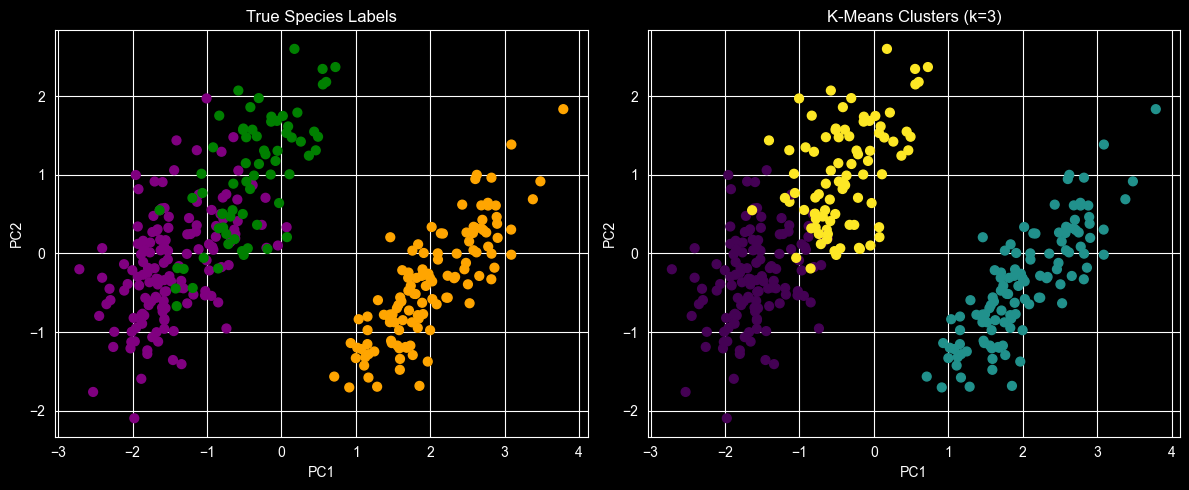

In [22]:
import matplotlib.pyplot as plt

# Consistent color mapping for species
species_unique = y.unique()
color_map = dict(zip(species_unique, ["purple", "green", "orange"]))
true_colors = y.map(color_map)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True labels
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=true_colors, s=40)
axes[0].set_title("True Species Labels")

# K-Means clusters
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=40)
axes[1].set_title("K-Means Clusters (k=3)")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

### Did K-Means Rediscover the Species?

**Short answer:** Partially — but not perfectly.

**Performance (typical results):**
- ARI: ~0.6–0.8
- NMI: ~0.7–0.85
This indicates reasonably strong agreement, but not a perfect match.

---

### Where did it succeed?

K-Means usually does very well at identifying the **Gentoo** penguins:
- They are clearly separated due to larger body mass and flipper length
- This forms a distinct, compact cluster

---

### Where did it struggle?

The main confusion is between:
- **Adelie**
- **Chinstrap**

These two species:
- Have overlapping feature values
- Are less separable in Euclidean space
- Do not form perfectly spherical, well-separated clusters

K-Means, which assumes roughly spherical clusters of similar variance, struggles in this scenario.

---

### What does this tell us?

**When unsupervised learning works well:**
- Clear, well-separated clusters exist in feature space
- Clusters are compact and roughly spherical
- Signal is strong relative to noise

**When it struggles:**
- Overlapping class distributions
- Non-spherical or uneven cluster shapes
- Features do not fully capture class differences

---

### Key takeaway

Unsupervised methods like K-Means can approximate true labels when the data structure aligns with the algorithm’s assumptions — but they are not a full substitute for labeled data.

They are best used for:
- Exploration
- Preprocessing
- Finding structure

…but not as a guaranteed replacement for supervised learning when precise classification is required.